In [9]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
model = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

In [4]:
# create a state
class LLMState(TypedDict):
    question: str
    answer: str

In [8]:
def llm_qa(state: LLMState) -> LLMState:
    # extract the question from the state
    question = state['question']

    # form a prompt 
    prompt = f"Answer the following question: {question}"

    # ask that question to the model(LLM)
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer
    return state

In [11]:
# create our graph
graph = StateGraph(LLMState)

# add a node to the graph
graph.add_node('llm_qa',llm_qa)

# add edge to the graph
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

# compile the graph to create a workflow
workflow = graph.compile()

# execute the workflow
initial_state = LLMState(question="How far is moon from the earth?")

final_state = workflow.invoke(initial_state)

print("Question:", final_state['question'])
print("Answer:", final_state['answer'])


Question: How far is moon from the earth?
Answer: The average distance from the Earth to the Moon is about 384,400 kilometers (238,855 miles). However, it's important to note that this distance can vary slightly due to the elliptical orbit of the Moon around the Earth. At its closest point (perigee), the Moon is about 363,104 kilometers (225,623 miles) from Earth, and at its farthest point (apogee), it is about 405,696 kilometers (252,088 miles) away.


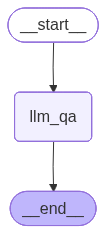

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())